# Continuous Flow Matching (unconditional, QM9 / ZINC)

Pipeline: **load → sample → VUN**.

## Setup

In [1]:
import os

REPO = "flow-matching-molecules"
if not os.path.isdir(REPO):
    !git clone https://github.com/Nico-Conti/flow-matching-molecules.git
os.chdir(REPO if os.path.basename(os.getcwd()) != REPO else ".")

!pip install -q uv
!uv pip install --system -q -e .   # installs deps + the package from pyproject
import sys; sys.path.insert(0, os.path.abspath("src"))  # flat src/ layout
print("cwd:", os.getcwd())

Cloning into 'flow-matching-molecules'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 120 (delta 52), reused 117 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 1.35 MiB | 15.55 MiB/s, done.
Resolving deltas: 100% (52/52), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 26.3 MB/s eta 0:00:00
cwd: /content/flow-matching-molecules


In [2]:
import torch
import train, evaluate
print(torch.__version__, "cuda:", torch.cuda.is_available())

2.11.0+cu128 cuda: True


/usr/local/lib/python3.12/dist-packages/torch_molecule/generator/molgpt/modeling_molgpt.py:112: SyntaxWarning: invalid escape sequence '\['
  self.pattern = "(\[[^\]]+]|<|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"


## QM9 — Load checkpoint
Load a trained model without retraining. `which="final"` loads the last checkpoint; `which="best"` loads the lowest-val-loss checkpoint.

qm9_fm_best.pt:   0%|          | 0.00/61.0M [00:00<?, ?B/s]

loaded best checkpoint (epoch 191, best_val=0.7057426894864728)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/132040 [00:00<?, ? examples/s]

reconstructed split: 99030 train / 13204 test


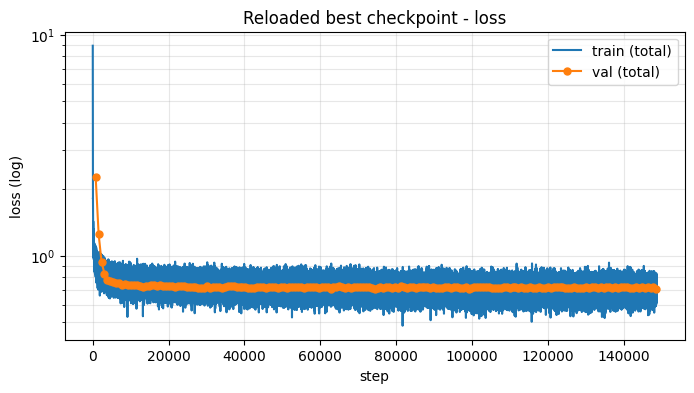

In [5]:
import os
import matplotlib.pyplot as plt
from checkpoint import repo_to_path, best_path, load_checkpoint, load_checkpoint_from_hf

repo  = "nico8771/qm9_fm"
which = "best"                      # "final" or "best"

local = repo_to_path(repo)
if which == "best":
    local = best_path(local)
fname = os.path.basename(local)

ck = load_checkpoint(local) if os.path.exists(local) else load_checkpoint_from_hf(repo, fname)

model        = ck["model"]
history      = ck["history"]
size_sampler = ck["size_sampler"]
train_smiles = ck["train_smiles"]
atom_vocab   = ck["atom_vocab"]
k_X, k_E     = ck["k_X"], ck["k_E"]
print(f"loaded {which} checkpoint (epoch {ck['epoch']}, best_val={ck['extra'].get('best_val')})")


from train import build_split

split_dataset = ck["extra"].get("dataset", "qm9")
split_seed    = ck["extra"].get("seed", 0)
split_subset  = None          # match the training call (QM9: None; ZINC 20k run: 20000)
sp = build_split(dataset=split_dataset, subset=split_subset, seed=split_seed,
                 val_frac=0.15, test_frac=0.10)
test_smiles = sp["test_smiles"]

assert sorted(sp["train_smiles"]) == sorted(train_smiles), \
    "split mismatch -- check split_subset/split_seed/val_frac/test_frac vs the training run"
print(f"reconstructed split: {len(sp['train_smiles'])} train / {len(test_smiles)} test")

# Plot loss from the reloaded history.
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"], label="train (total)", lw=1.5)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    spe = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * spe - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title(f"Reloaded {which} checkpoint - loss")
plt.show()


## QM9 — Evaluate (V/U/N + FCD)


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
out = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab, k_X, k_E,
                        n_samples=10000, batch=256, steps=100,
                        t_end=1, repair=False, fcd_ref=test_smiles,
                        device=device, method="fm_graph")
print(out)   # validity / uniqueness / novelty / repair_rate / fcd


{'validity': 0.9563, 'uniqueness': 0.9651782913311723, 'novelty': 0.581798483206934, 'n_generated': 10000, 'n_valid': 9563, 'n_unique': 9230, 'n_novel': 5370, 'repair_rate': 0.0, 'fcd': 1.1683723884930686}


## QM9 — Generated molecules (visual sample)


  0: CC1C=CC(C=O)N1C
  1: CC=CC1(C)C=CC1C
  2: CC1C=CCCCCC1
  3: CC1CC2C(C#N)OC12
  4: CC1N(CC=O)C1(C)C
  5: Nc1cc2c(cn1)OC2
  6: C=CC(O)OC
  7: CCC1=CCOCC1C
  8: O=CC12CC3CCC31C2
  9: CC#CCC
  10: CC1=NC=CON=CC1
  11: CC1CC(C)C(=O)O1


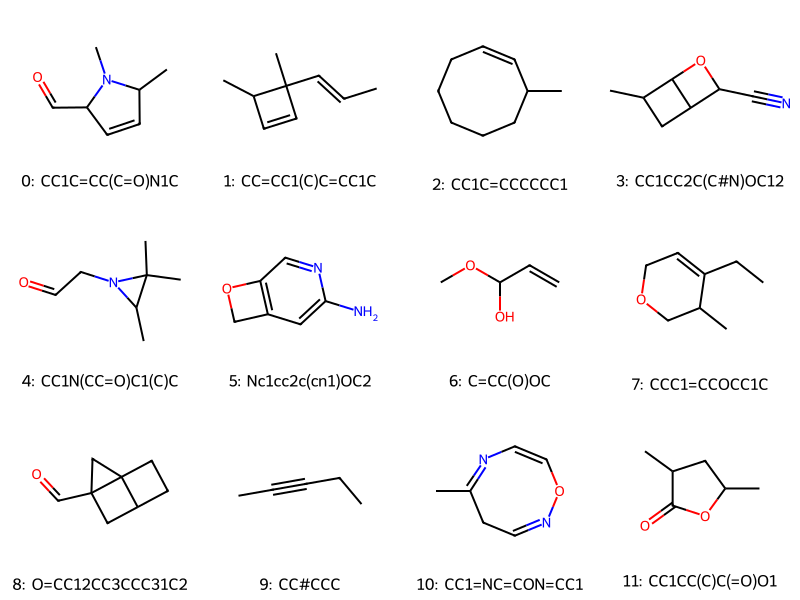

In [12]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from methods.fm_graph import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## ZINC — Load checkpoint
Same reload flow over the 9 neutral ZINC atom types; charges are recovered at decode via the partial-charge rebuild.

In [ ]:
import os
import matplotlib.pyplot as plt
from checkpoint import repo_to_path, best_path, load_checkpoint, load_checkpoint_from_hf

repo  = "nico8771/zinc_fm_test"
which = "best"                      # "final" or "best"

local = repo_to_path(repo)
if which == "best":
    local = best_path(local)
fname = os.path.basename(local)

ck = load_checkpoint(local) if os.path.exists(local) else load_checkpoint_from_hf(repo, fname)

model        = ck["model"]
history      = ck["history"]
size_sampler = ck["size_sampler"]
train_smiles = ck["train_smiles"]
atom_vocab   = ck["atom_vocab"]
k_X, k_E     = ck["k_X"], ck["k_E"]
print(f"loaded {which} checkpoint (epoch {ck['epoch']}, best_val={ck['extra'].get('best_val')})")


from train import build_split

split_dataset = ck["extra"].get("dataset", "qm9")
split_seed    = ck["extra"].get("seed", 0)
split_subset  = None          # match the training call (QM9: None; ZINC 20k run: 20000)
sp = build_split(dataset=split_dataset, subset=split_subset, seed=split_seed,
                 val_frac=0.15, test_frac=0.10)
test_smiles = sp["test_smiles"]

assert sorted(sp["train_smiles"]) == sorted(train_smiles), \
    "split mismatch -- check split_subset/split_seed/val_frac/test_frac vs the training run"
print(f"reconstructed split: {len(sp['train_smiles'])} train / {len(test_smiles)} test")

# Plot loss from the reloaded history.
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"], label="train (total)", lw=1.5)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    spe = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * spe - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title(f"Reloaded {which} checkpoint - loss")
plt.show()


## ZINC — Evaluate (V/U/N + FCD)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab, k_X, k_E,
                        n_samples=1000, batch=256, steps=100,
                        repair=False, fcd_ref=test_smiles, partial_charges=True,
                        device=device, method="fm_graph")
print(vun)


## ZINC — Generated molecules (visual sample)


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import build_mol_partial_charges, largest_fragment
from methods.fm_graph import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m = build_mol_partial_charges(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}")
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")
